Projet réalisé par Nadim Coindet  
Master 1 Mathématiques — Sorbonne Université  
Projet personnel en finance quantitative et gestion des risques

# Analyse comparative du risque entre actions et cryptomonnaies

## Objectif du projet

Ce projet vise à étudier et comparer le profil de risque des actions traditionnelles et des cryptomonnaies à l’aide d’outils de finance quantitative et de gestion des risques.

L’analyse porte sur plusieurs dimensions :
- les rendements et volatilités,
- les distributions statistiques des rendements,
- les mesures de risque extrême telles que la Value-at-Risk (VaR) et l’Expected Shortfall (ES),
- ainsi que les corrélations entre actifs.

Une attention particulière est accordée à l’impact des cryptomonnaies dans un portefeuille diversifié, afin d’évaluer dans quelle mesure leur forte volatilité peut être compensée par des effets de diversification.

L’objectif est ainsi d’analyser les différences de comportement entre actifs traditionnels et actifs crypto, tout en étudiant les implications de ces caractéristiques dans une logique de gestion de portefeuille et de risk management.


## Plan du projet

1. Importation et préparation des données  
2. Analyse des rendements et volatilités  
3. Étude des distributions de rendements  
4. Analyse des mesures de risque (VaR et Expected Shortfall)  
5. Corrélations entre actifs  
6. Construction de portefeuilles mixtes  
7. Conclusion

# Importation des bibliothèques

Les bibliothèques Python suivantes sont utilisées :
- `pandas` pour la manipulation des données,
- `numpy` pour les calculs numériques,
- `matplotlib` pour les visualisations,
- `yfinance` pour récupérer les données financières historiques.
- `scipy.stats`pour les outils statistiques et les distributions probabilistes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm, skew,  kurtosis

# Sélection des actifs étudiés

Les actifs retenus pour cette étude sont :

## Actions
- Apple (`AAPL`)
- Microsoft (`MSFT`)
- SPDR S&P 500 ETF (`SPY`)

## Cryptomonnaies
- Bitcoin (`BTC-USD`)
- Ethereum (`ETH-USD`)

Ces actifs permettent de comparer :
- des entreprises technologiques majeures,
- un indice représentatif du marché américain,
- et les deux principales cryptomonnaies du marché.

In [2]:
tickers = ["AAPL", "MSFT", "SPY", "BTC-USD", "ETH-USD"]

# 1. Importation et préparation des données

Les données historiques de prix sont récupérées via l’API Yahoo Finance à l’aide de la bibliothèque `yfinance`.

La période étudiée s’étend du 1er janvier 2020 au 1er janvier 2026.

Seuls les prix de clôture ("Close") sont conservés pour l’analyse.

In [3]:
data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01"
)["Close"]

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,BTC-USD,ETH-USD,MSFT,SPY
Date,,,,,
2020-01-01,NaN,7200.174316,130.802002,NaN,NaN
2020-01-02,72.333878,6985.470215,127.410179,152.158417,296.888153
2020-01-03,71.630653,7344.884277,134.171707,150.263748,294.640045
2020-01-04,NaN,7410.656738,135.069366,NaN,NaN
2020-01-05,NaN,7411.317383,136.276779,NaN,NaN


# Nettoyage des données

Une différence importante apparaît entre les marchés actions et les cryptomonnaies :

- les marchés actions ne cotent pas le week-end,
- les cryptomonnaies sont échangées 24h/24 et 7j/7.

Cela entraîne la présence de valeurs manquantes (`NaN`) pour les actifs actions durant les week-ends.

Afin de travailler sur des observations cohérentes entre tous les actifs, les lignes contenant des valeurs manquantes sont supprimées.

In [4]:
data_clean = data.dropna()
data_clean.head()


Ticker,AAPL,BTC-USD,ETH-USD,MSFT,SPY
Date,,,,,
2020-01-02,72.333878,6985.470215,127.410179,152.158417,296.888153
2020-01-03,71.630653,7344.884277,134.171707,150.263748,294.640045
2020-01-06,72.201393,7769.219238,144.304153,150.652176,295.764191
2020-01-07,71.861855,8163.692383,143.543991,149.278534,294.932556
2020-01-08,73.017838,8079.862793,141.258133,151.656311,296.504425


# Visualisation des prix

Un premier graphique des prix permet d’observer l’évolution des différents actifs sur la période étudiée.

Cette visualisation met déjà en évidence :
- une forte croissance de certains actifs,
- mais également une volatilité beaucoup plus importante sur les cryptomonnaies.


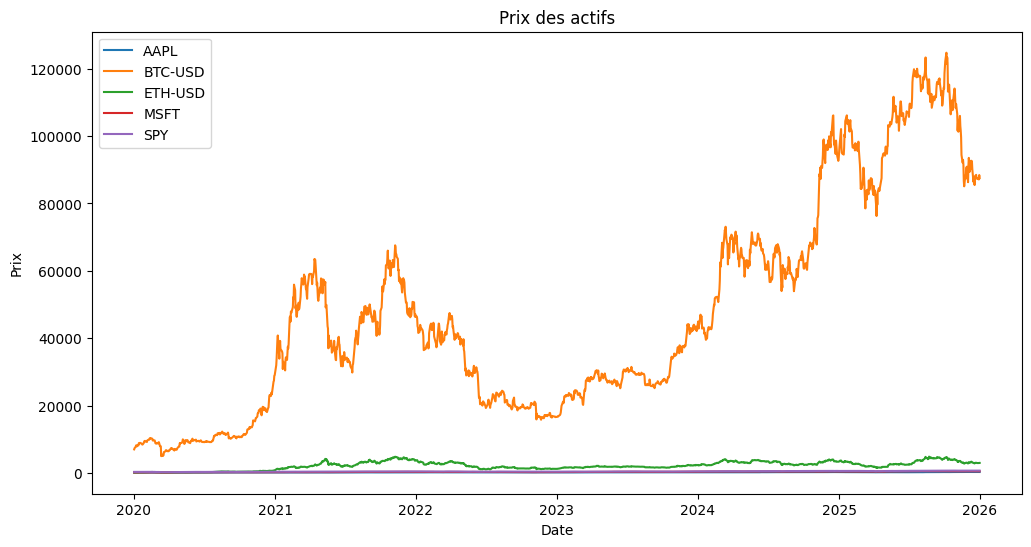

In [5]:
plt.figure(figsize=(12,6))

for column in data_clean.columns:
    plt.plot(data_clean.index, data_clean[column], label=column)

plt.title("Prix des actifs")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()

plt.show()

# Visualisation des prix normalisés

Les actifs étudiés présentent des niveaux de prix très différents, ce qui rend une comparaison directe difficile.

Afin de comparer correctement leur évolution relative sur la période étudiée, les prix sont normalisés en base 100 au début de l’échantillon.

Cette approche permet de visualiser :
- les performances relatives,
- les tendances de marché,
- et les différences de comportement entre actifs traditionnels et cryptomonnaies.

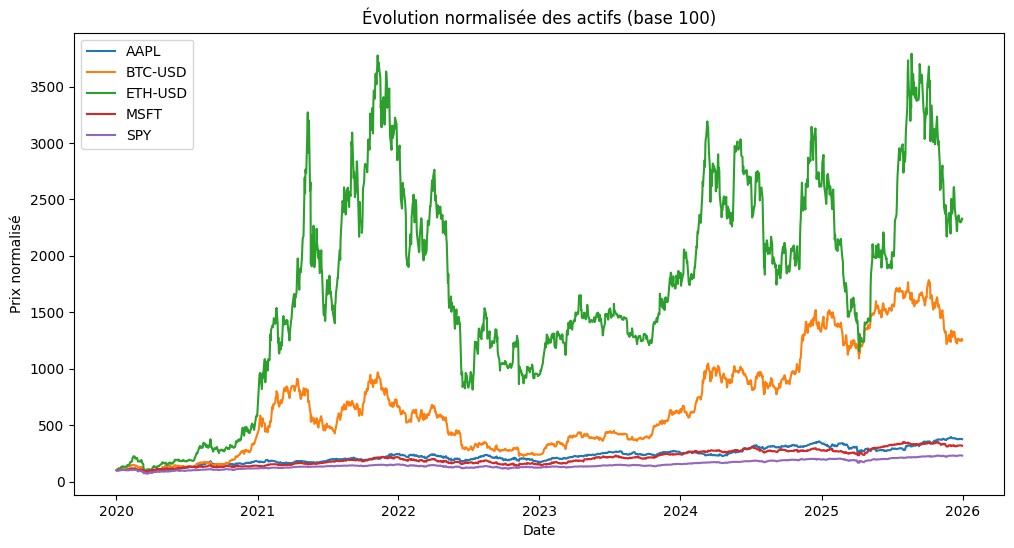

In [6]:
# Normalisation des prix (base 100)
normalized_data = data_clean / data_clean.iloc[0] * 100

plt.figure(figsize=(12,6))

for column in normalized_data.columns:
    plt.plot(
        normalized_data.index,
        normalized_data[column],
        label=column
    )

plt.title("Évolution normalisée des actifs (base 100)")
plt.xlabel("Date")
plt.ylabel("Prix normalisé")
plt.legend()

plt.show()

# 2. Analyse des rendements et volatilités
## Calcul des rendements

L’analyse du risque ne s’effectue généralement pas directement sur les prix, mais sur les rendements.

Les rendements journaliers sont calculés à l’aide de la variation relative des prix :

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

où :
- $P_t$ représente le prix à la date $t$,
- $P_{t-1}$ représente le prix de la veille.

Les rendements permettent de mesurer les variations relatives des actifs indépendamment de leur niveau de prix.


In [7]:
returns = data_clean.pct_change().dropna()

print(returns.head())

Ticker          AAPL   BTC-USD   ETH-USD      MSFT       SPY
Date                                                        
2020-01-03 -0.009722  0.051452  0.053069 -0.012452 -0.007572
2020-01-06  0.007968  0.057773  0.075519  0.002585  0.003815
2020-01-07 -0.004703  0.050774 -0.005268 -0.009118 -0.002812
2020-01-08  0.016086 -0.010269 -0.015924  0.015928  0.005330
2020-01-09  0.021241 -0.024851 -0.016133  0.012493  0.006780


# Calcul de la volatilité

La volatilité correspond à l’écart-type des rendements.

Elle mesure l’ampleur moyenne des fluctuations d’un actif :
- une volatilité élevée indique un actif plus risqué,
- une volatilité faible indique un actif plus stable.

La volatilité annualisée est calculée différemment selon la classe d’actifs :

- les actions sont annualisées sur une base de 252 jours de bourse,
- les cryptomonnaies sur une base de 365 jours.

Les formules utilisées sont :

$$
\sigma_{actions} = \sigma_{journalière} \times \sqrt{252}
$$

$$
\sigma_{crypto} = \sigma_{journalière} \times \sqrt{365}
$$


In [8]:
# Volatilité journalière
volatility_daily = returns.std()

# Annualisation adaptée selon la classe d'actifs
volatility_annual = pd.Series(index=volatility_daily.index, dtype=float)

# Actions
stock_tickers = ["AAPL", "MSFT", "SPY"]

# Cryptos
crypto_tickers = ["BTC-USD", "ETH-USD"]

# Annualisation actions
volatility_annual[stock_tickers] = (
    volatility_daily[stock_tickers] * np.sqrt(252)
)

# Annualisation cryptos
volatility_annual[crypto_tickers] = (
    volatility_daily[crypto_tickers] * np.sqrt(365)
)

# Affichage en pourcentage
print("Volatilité annualisée (%) :\n")
print((volatility_annual * 100).round(2))

Volatilité annualisée (%) :

Ticker
AAPL       31.81
BTC-USD    73.89
ETH-USD    99.68
MSFT       29.55
SPY        20.75
dtype: float64


# Premières observations

Les résultats obtenus montrent une différence très importante entre actions et cryptomonnaies.

Les cryptomonnaies présentent une volatilité annualisée nettement supérieure aux actifs actions traditionnels :
- le S&P 500 affiche une volatilité relativement modérée,
- tandis que Bitcoin et Ethereum présentent des fluctuations beaucoup plus importantes.

Cette différence reflète :
- une plus forte instabilité des marchés crypto,
- une sensibilité accrue aux mouvements spéculatifs,
- et un risque de marché significativement plus élevé.

# Visualisation des rendements journaliers

Les rendements journaliers permettent d’observer directement les fluctuations des actifs.

Contrairement aux prix, ils mettent en évidence :
- l’intensité des mouvements de marché,
- la fréquence des variations extrêmes,
- et les différences de stabilité entre classes d’actifs.

L’analyse des rendements est essentielle en gestion des risques car la plupart des mesures de risque sont calculées à partir de ces variations.

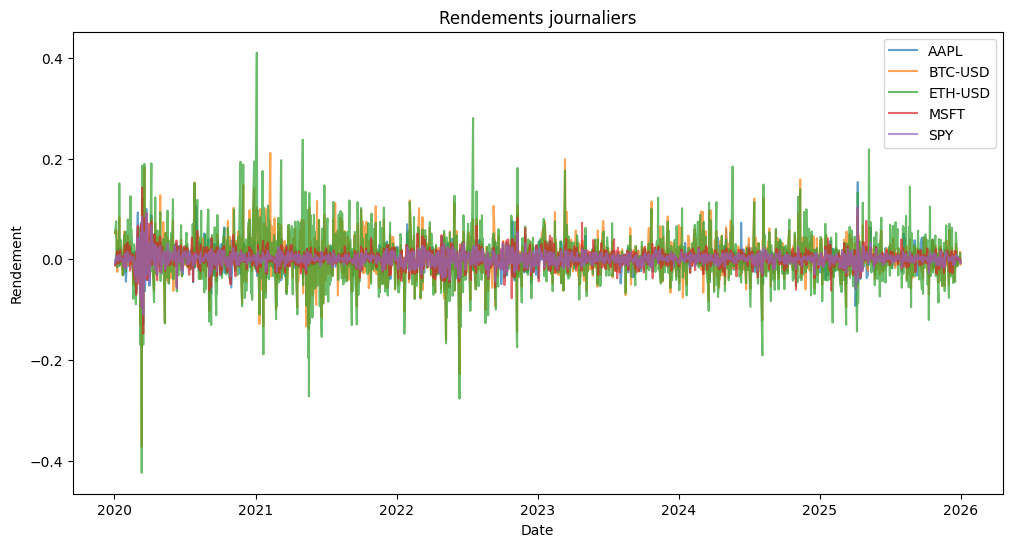

In [9]:
plt.figure(figsize=(12,6))

for column in returns.columns:
    plt.plot(
        returns.index,
        returns[column],
        label=column,
        alpha=0.7
    )

plt.title("Rendements journaliers")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.legend()

plt.show()

# Analyse des fluctuations journalières

Les cryptomonnaies présentent des variations journalières beaucoup plus importantes que les actifs actions traditionnels.

On observe notamment sur Ethereum plusieurs journées avec des rendements proches de ±40 %, ce qui montre à quel point les marchés crypto peuvent être instables sur de courtes périodes.

À l’inverse, les actions et l’indice S&P 500 présentent des fluctuations plus limitées et plus régulières.

Cette première observation met déjà en évidence un niveau de risque bien plus élevé sur les actifs crypto.

# 3. Étude des distributions de rendements

L’étude de la distribution des rendements permet d’analyser plus finement le comportement des actifs financiers.

Les histogrammes mettent en évidence :
- la dispersion des rendements,
- la fréquence des variations extrêmes,
- et les différences de stabilité entre actifs traditionnels et cryptomonnaies.

En gestion des risques, l’analyse des distributions est essentielle car les pertes importantes sont souvent liées à des événements rares mais extrêmes.

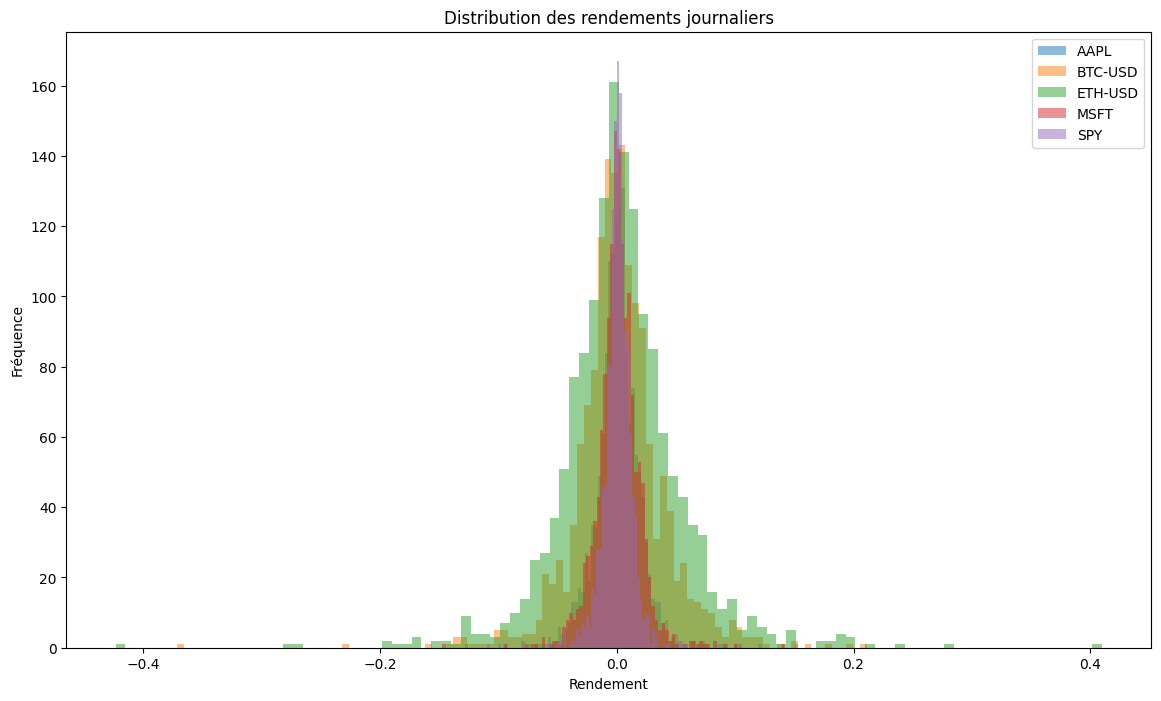

In [10]:
plt.figure(figsize=(14,8))

for column in returns.columns:
    plt.hist(
        returns[column],
        bins=100,
        alpha=0.5,
        label=column
    )

plt.title("Distribution des rendements journaliers")
plt.xlabel("Rendement")
plt.ylabel("Fréquence")
plt.legend()

plt.show()

# Approximation des rendements par une loi normale

L’observation des histogrammes de rendements journaliers montre une forme qui rappelle partiellement une distribution gaussienne (ou loi normale) :
- les rendements semblent globalement centrés autour d’une moyenne proche de zéro,
- les petites variations sont les plus fréquentes,
- tandis que les variations importantes apparaissent plus rarement.

Cette observation conduit naturellement à s’interroger sur la pertinence d’une modélisation des rendements financiers par une loi normale, hypothèse largement utilisée en finance quantitative.

En pratique, de nombreux modèles financiers reposent sur cette approximation, notamment :
- certaines approches de gestion des risques,
- les modèles classiques de valorisation,
- et plusieurs méthodes de calcul de la Value-at-Risk (VaR).

Afin d’évaluer la qualité de cette hypothèse, une loi normale est estimée pour chaque actif à partir :
- de la moyenne empirique des rendements,
- et de leur écart-type empirique.

Les distributions théoriques obtenues sont ensuite comparées aux distributions réelles des rendements observés.

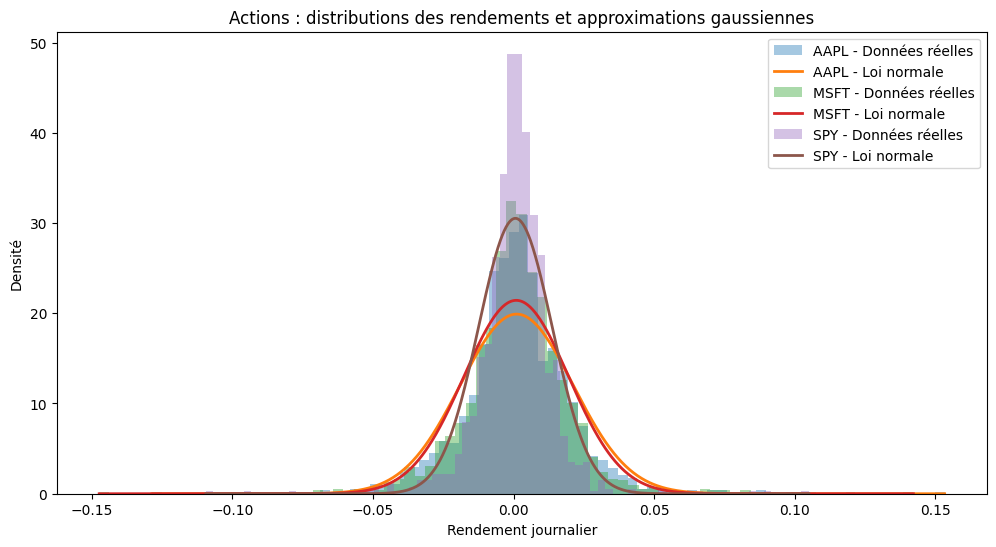

In [11]:
stock_tickers = ["AAPL", "MSFT", "SPY"]

plt.figure(figsize=(12,6))

for column in stock_tickers:
    asset_returns = returns[column]
    mu = asset_returns.mean()
    sigma = asset_returns.std()

    plt.hist(
        asset_returns,
        bins=80,
        density=True,
        alpha=0.4,
        label=f"{column} - Données réelles"
    )

    x = np.linspace(asset_returns.min(), asset_returns.max(), 1000)
    normal_density = norm.pdf(x, mu, sigma)

    plt.plot(
        x,
        normal_density,
        linewidth=2,
        label=f"{column} - Loi normale"
    )

plt.title("Actions : distributions des rendements et approximations gaussiennes")
plt.xlabel("Rendement journalier")
plt.ylabel("Densité")
plt.legend()
plt.show()

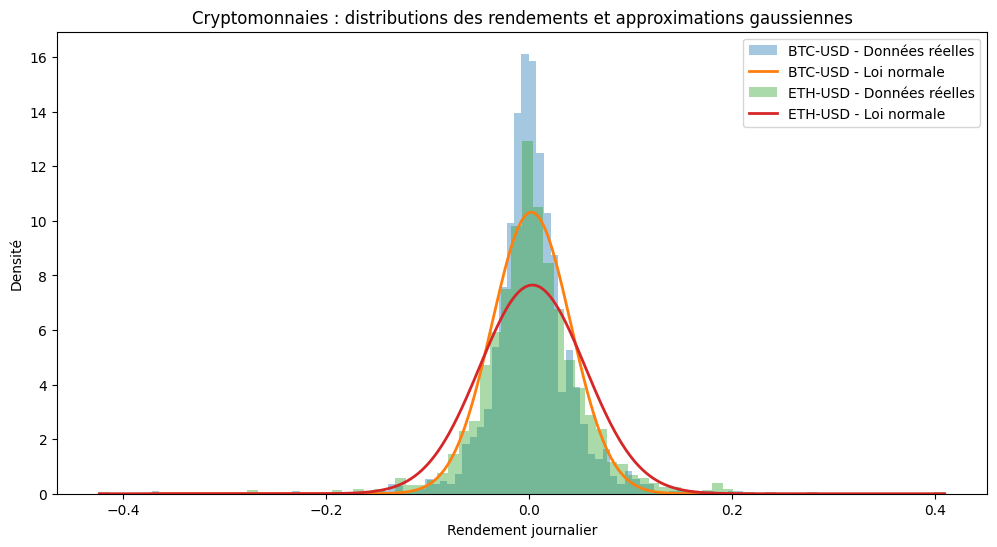

In [12]:
crypto_tickers = ["BTC-USD", "ETH-USD"]

plt.figure(figsize=(12,6))

for column in crypto_tickers:
    asset_returns = returns[column]
    mu = asset_returns.mean()
    sigma = asset_returns.std()

    plt.hist(
        asset_returns,
        bins=80,
        density=True,
        alpha=0.4,
        label=f"{column} - Données réelles"
    )

    x = np.linspace(asset_returns.min(), asset_returns.max(), 1000)
    normal_density = norm.pdf(x, mu, sigma)

    plt.plot(
        x,
        normal_density,
        linewidth=2,
        label=f"{column} - Loi normale"
    )

plt.title("Cryptomonnaies : distributions des rendements et approximations gaussiennes")
plt.xlabel("Rendement journalier")
plt.ylabel("Densité")
plt.legend()
plt.show()

# Analyse des distributions et limites de l’hypothèse gaussienne

Les distributions observées restent assez proches d’une forme gaussienne dans leur partie centrale, mais plusieurs écarts importants apparaissent, surtout pour les cryptomonnaies.

Les actifs crypto présentent des distributions plus étalées ainsi qu’un nombre plus important de rendements extrêmes.

On observe notamment des queues de distribution plus épaisses que celles prévues par une loi normale classique, ce qui signifie que les événements extrêmes sont plus fréquents que dans un modèle gaussien théorique.

Les actions traditionnelles semblent un peu plus proches d’une distribution normale, même si des écarts importants restent visibles lors de certaines périodes de marché stressées.

Ces observations montrent que l’hypothèse de normalité peut rapidement devenir limitée lorsqu’on cherche à modéliser des actifs très volatils comme les cryptomonnaies.

# Statistiques descriptives des rendements

Après l’analyse visuelle des distributions, on calcule plusieurs indicateurs statistiques afin de comparer quantitativement les actifs.

Les indicateurs étudiés sont :
- la moyenne des rendements journaliers,
- la volatilité journalière,
- le minimum et le maximum observés,
- l’asymétrie de la distribution (skewness),
- l’épaisseur des queues de distribution (kurtosis).

Ces mesures permettent de mieux comprendre le profil de risque de chaque actif.

In [13]:
stats = pd.DataFrame(index=returns.columns)

stats["Moyenne journalière (%)"] = returns.mean() * 100
stats["Volatilité journalière (%)"] = returns.std() * 100
stats["Minimum journalier (%)"] = returns.min() * 100
stats["Maximum journalier (%)"] = returns.max() * 100
stats["Skewness"] = returns.apply(skew)
stats["Kurtosis"] = returns.apply(kurtosis)

stats = stats.round(2)

stats

,Moyenne journalière (%),Volatilité journalière (%),Minimum journalier (%),Maximum journalier (%),Skewness,Kurtosis
Ticker,,,,,,
AAPL,0.11,2.00,-12.86,15.33,0.28,6.77
BTC-USD,0.24,3.87,-37.17,21.11,-0.41,9.04
ETH-USD,0.35,5.22,-42.35,40.99,0.08,8.27
MSFT,0.09,1.86,-14.74,14.22,0.11,7.51
SPY,0.06,1.31,-10.94,10.50,-0.26,13.00


# Analyse des statistiques descriptives

Les statistiques obtenues confirment les différences importantes entre actifs traditionnels et cryptomonnaies.

Les cryptomonnaies présentent :
- une volatilité beaucoup plus élevée,
- des rendements extrêmes plus importants,
- ainsi qu’une dispersion nettement supérieure aux actifs actions.

Les valeurs élevées de kurtosis montrent également que les distributions de rendements possèdent des queues épaisses ("fat tails"), ce qui signifie que les événements extrêmes sont plus fréquents qu’avec une loi normale classique.

Même les actifs actions présentent donc une certaine non-normalité des rendements, bien que le phénomène soit encore plus marqué sur les cryptomonnaies.

Ces résultats montrent pourquoi les mesures de risque extrême sont particulièrement importantes lorsqu’on analyse des actifs très volatils.

# 4. Analyse des mesures de risque (VaR et Expected Shortfall)
## Value-at-Risk historique (VaR)

La Value-at-Risk (VaR) est une mesure centrale en gestion des risques.

Elle permet d’estimer la perte potentielle maximale d’un actif ou d’un portefeuille pour un niveau de confiance donné sur un horizon temporel défini.

Dans cette étude, on calcule la VaR historique à 95 % sur les rendements journaliers.

La méthode historique repose directement sur les données observées :
- aucune hypothèse de normalité n’est imposée,
- les pertes passées servent à estimer les pertes potentielles futures.

La VaR à 95 % correspond ici au quantile de niveau 5 % de la distribution des rendements.

In [14]:
# Calcul de la VaR historique à 95%
var_95 = returns.quantile(0.05)

# Affichage en pourcentage
var_95_percent = (var_95 * 100).round(2)

print("VaR historique journalière à 95% (%) :\n")
print(var_95_percent)

VaR historique journalière à 95% (%) :

Ticker
AAPL      -3.07
BTC-USD   -5.49
ETH-USD   -6.95
MSFT      -2.73
SPY       -1.81
Name: 0.05, dtype: float64


# Analyse de la Value-at-Risk historique

Les résultats obtenus mettent clairement en évidence les différences de risque entre actifs traditionnels et cryptomonnaies.

Les actifs actions présentent des pertes journalières extrêmes relativement limitées :
- le S&P 500 affiche la VaR la plus faible,
- tandis que les actions individuelles présentent un risque légèrement supérieur.

À l’inverse, les cryptomonnaies présentent des pertes potentielles beaucoup plus importantes :
- Bitcoin affiche déjà une VaR significativement supérieure aux actions,
- Ethereum présente le niveau de risque le plus élevé parmi les actifs étudiés.

Ces résultats traduisent :
- une volatilité plus importante,
- une fréquence accrue de mouvements extrêmes,
- et un risque de marché plus élevé sur les actifs crypto.

La VaR historique permet ici de mesurer directement les pertes observées sans supposer de distribution théorique particulière.

# Value-at-Risk paramétrique

Contrairement à la VaR historique, la VaR paramétrique repose sur une hypothèse de distribution des rendements.

Dans cette approche, les rendements sont supposés suivre une loi normale caractérisée par :
- une moyenne empirique,
- et une volatilité empirique.

La VaR paramétrique à 95 % est alors calculée à partir du quantile de la loi normale.

Cette méthode est largement utilisée en finance quantitative car elle est simple et rapide à implémenter.

Cependant, sa pertinence dépend fortement de la validité de l’hypothèse gaussienne des rendements.

In [15]:
# Quantile de la loi normale à 5%
z_score = norm.ppf(0.05)

# Moyennes et volatilités des rendements
mu = returns.mean()
sigma = returns.std()

# VaR paramétrique
var_parametric = mu + z_score * sigma

# Affichage en pourcentage
var_parametric_percent = (var_parametric * 100).round(2)

print("VaR paramétrique journalière à 95% (%) :\n")
print(var_parametric_percent)

VaR paramétrique journalière à 95% (%) :

Ticker
AAPL      -3.19
BTC-USD   -6.12
ETH-USD   -8.24
MSFT      -2.97
SPY       -2.09
dtype: float64


In [16]:
comparaison = pd.DataFrame({
    "VaR Historique (%)": (var_95 * 100).round(2),
    "VaR Paramétrique (%)": (var_parametric * 100).round(2)
})

comparaison

,VaR Historique (%),VaR Paramétrique (%)
Ticker,,
AAPL,-3.07,-3.19
BTC-USD,-5.49,-6.12
ETH-USD,-6.95,-8.24
MSFT,-2.73,-2.97
SPY,-1.81,-2.09


# Comparaison entre VaR historique et VaR paramétrique

Les résultats montrent que les valeurs de VaR historique et de VaR paramétrique restent relativement proches pour l’ensemble des actifs étudiés.

Dans cette étude, la VaR paramétrique apparaît même légèrement plus conservatrice que la VaR historique, en particulier pour les cryptomonnaies.

Ce résultat s’explique notamment par la très forte volatilité empirique observée sur les actifs crypto :
- l’écart-type élevé conduit à une distribution normale théorique très dispersée,
- ce qui augmente mécaniquement la VaR paramétrique.

Cependant, cette proximité entre les deux mesures ne signifie pas que les rendements suivent réellement une loi normale.

Les analyses précédentes ont mis en évidence :
- des distributions à queues épaisses,
- des événements extrêmes fréquents,
- et des écarts importants par rapport à une distribution gaussienne idéale.

Les limites de l’hypothèse normale deviennent généralement plus visibles sur des mesures de risque plus extrêmes, notamment :
- la VaR à 99 %,
- ou l’Expected Shortfall (ES).

# Expected Shortfall (ES)

La Value-at-Risk présente une limite importante :
elle indique un seuil de perte, mais ne mesure pas l’ampleur moyenne des pertes au-delà de ce seuil.

L’Expected Shortfall (ES), également appelé Conditional Value-at-Risk (CVaR), permet de compléter cette analyse.

L’Expected Shortfall à 95 % correspond à :
- la perte moyenne observée dans les 5 % pires scénarios.

Cette mesure est particulièrement pertinente pour les distributions à queues épaisses, car elle prend en compte les événements extrêmes situés au-delà de la VaR.

In [17]:
# Calcul de l'Expected Shortfall historique à 95%

expected_shortfall = {}

for column in returns.columns:

    # Rendements inférieurs à la VaR historique
    tail_losses = returns[column][returns[column] <= var_95[column]]

    # Moyenne des pertes extrêmes
    expected_shortfall[column] = tail_losses.mean()

# Conversion en série pandas
expected_shortfall = pd.Series(expected_shortfall)

# Affichage en pourcentage
expected_shortfall_percent = (expected_shortfall * 100).round(2)

print("Expected Shortfall historique à 95% (%) :\n")
print(expected_shortfall_percent)

Expected Shortfall historique à 95% (%) :

AAPL       -4.46
BTC-USD    -8.60
ETH-USD   -11.35
MSFT       -4.13
SPY        -3.13
dtype: float64


In [18]:
risk_comparaison = pd.DataFrame({
    "VaR 95% (%)": (var_95 * 100).round(2),
    "Expected Shortfall 95% (%)": (expected_shortfall * 100).round(2)
})

risk_comparaison

,VaR 95% (%),Expected Shortfall 95% (%)
AAPL,-3.07,-4.46
BTC-USD,-5.49,-8.60
ETH-USD,-6.95,-11.35
MSFT,-2.73,-4.13
SPY,-1.81,-3.13


# Analyse de l’Expected Shortfall

Les résultats montrent que l’Expected Shortfall est systématiquement plus sévère que la Value-at-Risk pour tous les actifs étudiés.

L’écart est particulièrement marqué pour Bitcoin et Ethereum :
- lorsque les cryptomonnaies entrent dans les pires scénarios observés,
- les pertes moyennes deviennent très importantes.

Autrement dit, les cryptomonnaies ne présentent pas seulement une volatilité élevée :
elles subissent également des pertes extrêmes plus violentes lors des périodes défavorables.

Ces résultats confirment ce qui avait déjà été observé avec les distributions de rendements :
les actifs crypto présentent un risque extrême beaucoup plus important que les actifs actions traditionnels.

L’Expected Shortfall apparaît donc ici comme une mesure particulièrement utile pour analyser les risques de marché extrêmes.

# 5. Corrélations entre actifs

La volatilité individuelle d’un actif ne suffit pas à évaluer le risque d’un portefeuille.

En gestion de portefeuille, il est également essentiel d’étudier les corrélations entre actifs :
- deux actifs fortement corrélés ont tendance à évoluer dans le même sens,
- tandis que des actifs faiblement corrélés peuvent améliorer la diversification.

L’intérêt potentiel d’un actif dans un portefeuille dépend donc non seulement de son risque individuel, mais aussi de son comportement par rapport aux autres actifs.

L’analyse des corrélations permet ici d’évaluer si les cryptomonnaies peuvent apporter un effet de diversification malgré leur forte volatilité.

In [19]:
correlation_matrix = returns.corr()

print(correlation_matrix.round(2))

Ticker   AAPL  BTC-USD  ETH-USD  MSFT   SPY
Ticker                                     
AAPL     1.00     0.29     0.30  0.71  0.78
BTC-USD  0.29     1.00     0.81  0.32  0.38
ETH-USD  0.30     0.81     1.00  0.32  0.38
MSFT     0.71     0.32     0.32  1.00  0.80
SPY      0.78     0.38     0.38  0.80  1.00


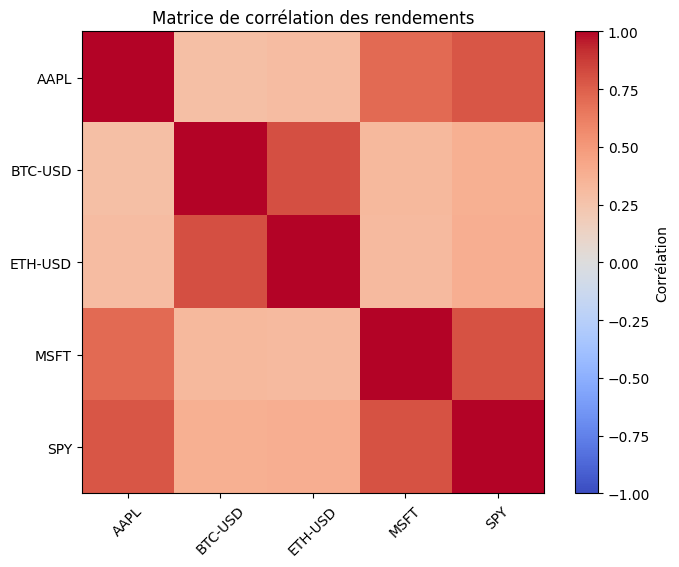

In [20]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Corrélation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Matrice de corrélation des rendements")

plt.show()

# Analyse des corrélations

Les résultats montrent que les actifs actions traditionnels sont fortement corrélés entre eux :
Apple, Microsoft et le S&P 500 évoluent souvent dans le même sens.

Bitcoin et Ethereum présentent également une forte corrélation mutuelle, ce qui est cohérent avec leur appartenance au même marché crypto.

En revanche, les corrélations entre cryptomonnaies et actifs traditionnels restent plus modérées.

Les cryptomonnaies ne semblent donc pas totalement indépendantes des marchés financiers traditionnels :
elles suivent globalement les grandes tendances du marché, notamment lors des périodes d’euphorie ou de stress.

Cependant, leurs corrélations plus faibles avec les actions peuvent malgré tout apporter un certain effet de diversification dans un portefeuille mixte.

# 6. Construction de portefeuilles mixtes

Après l’analyse individuelle des actifs, l’étude est étendue à des portefeuilles composés de plusieurs classes d’actifs.

L’objectif est d’évaluer l’impact de l’intégration des cryptomonnaies dans un portefeuille traditionnel d’actions.

Deux portefeuilles sont construits :
- un portefeuille composé uniquement d’actifs actions,
- un portefeuille mixte intégrant une exposition modérée aux cryptomonnaies.

Cette approche permet d’étudier :
- l’effet de diversification,
- l’évolution du risque global,
- et l’impact des corrélations entre actifs.

In [21]:
# Définition des poids des portefeuilles

weights_traditional = np.array([0.30, 0.30, 0.40])
weights_mixed = np.array([0.25, 0.25, 0.30, 0.10, 0.10])

# Rendements des actifs

traditional_returns = returns[["AAPL", "MSFT", "SPY"]]
mixed_returns = returns[["AAPL", "MSFT", "SPY", "BTC-USD", "ETH-USD"]]

# Rendements des portefeuilles

portfolio_traditional = traditional_returns.dot(weights_traditional)
portfolio_mixed = mixed_returns.dot(weights_mixed)

In [22]:
# Fonction de calcul des statistiques de risque

def portfolio_stats(portfolio_returns):

    mean_return = portfolio_returns.mean() * 100

    volatility = portfolio_returns.std() * np.sqrt(252) * 100 #La volatilité des portefeuilles est annualisée sur une base de 252 jours,
    #car les rendements utilisés sont calculés après alignement des actifs sur les jours communs de cotation, correspondant aux jours d’ouverture des marchés actions.

    var_95 = portfolio_returns.quantile(0.05) * 100

    es_95 = portfolio_returns[
        portfolio_returns <= portfolio_returns.quantile(0.05)
    ].mean() * 100

    return pd.Series({
        "Rendement moyen journalier (%)": round(mean_return, 3),
        "Volatilité annualisée (%)": round(volatility, 2),
        "VaR 95% (%)": round(var_95, 2),
        "Expected Shortfall 95% (%)": round(es_95, 2)
    })

# Tableau comparatif

portfolio_comparison = pd.DataFrame({
    "Portefeuille traditionnel":
        portfolio_stats(portfolio_traditional),

    "Portefeuille mixte":
        portfolio_stats(portfolio_mixed)
})

portfolio_comparison

,Portefeuille traditionnel,Portefeuille mixte
Rendement moyen journalier (%),0.086,0.129
Volatilité annualisée (%),24.510,28.000
VaR 95% (%),-2.270,-2.450
Expected Shortfall 95% (%),-3.570,-4.080


# Analyse des portefeuilles

Les résultats montrent qu’une exposition modérée aux cryptomonnaies modifie clairement le profil risque/rendement du portefeuille.

Le portefeuille mixte présente :
- un rendement moyen plus élevé,
- mais aussi une hausse de la volatilité et des mesures de risque extrême.

Cependant, l’augmentation du risque reste relativement limitée par rapport à la très forte volatilité des cryptomonnaies prises individuellement.

Cela s’explique notamment par les effets de diversification et par des corrélations imparfaites entre actifs crypto et actifs traditionnels.

Les cryptomonnaies apparaissent donc comme des actifs très risqués individuellement, mais qui peuvent malgré tout avoir un intérêt dans un portefeuille diversifié lorsqu’ils sont utilisés de manière modérée.

# 7. Conclusion

Cette étude a permis de comparer le profil de risque des actions traditionnelles et des cryptomonnaies à travers plusieurs outils de finance quantitative et de gestion des risques.

Les analyses menées ont mis en évidence :
- une volatilité nettement plus élevée sur les actifs crypto,
- des distributions de rendements présentant des queues épaisses,
- ainsi qu’une fréquence plus importante d’événements extrêmes.

Les mesures de risque telles que la Value-at-Risk et l’Expected Shortfall confirment que les cryptomonnaies présentent un risque de marché significativement supérieur aux actifs actions traditionnels.

Cependant, l’analyse des corrélations et la construction d’un portefeuille mixte montrent qu’une exposition modérée aux cryptomonnaies peut néanmoins apporter un certain effet de diversification.

Ce projet illustre ainsi l’importance :
- des distributions de rendements,
- des corrélations entre actifs,
- et des mesures de risque extrême dans l’évaluation d’un portefeuille financier.

Cette étude montre qu’une approche purement fondée sur la volatilité peut être insuffisante pour évaluer certains actifs très spéculatifs comme les cryptomonnaies, et souligne l’importance des mesures de risque extrême dans la construction de portefeuille.